In [3]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
from sklearn.linear_model import HuberRegressor
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

PARQUET_DIR  = Path("/nvme1/users/md962/glacier/Glacier Project/Merged")
SIM_DIR      = Path("/nvme1/users/md962/glacier/Glacier Project/Sim_Merged/")
RESULTS_DIR  = Path("/nvme1/users/md962/glacier/Glacier Project/Results")
RGI_PATH     = Path("/nvme1/users/md962/glacier/Glacier Project/rgi70_peru.geojson")

PIXEL_AREA_KM2 = (10 * 10) / 1e6  # km²
MIN_GLACIER_KM2 = 0.1              # minimum glacier size threshold
MIN_PIXELS = 10                    # minimum pixels to include glacier in fit

print("Imports done")

Imports done


In [4]:
# Load 2017 data (training parquets)
print("Loading 2017 pixels...")
dfs_2017 = []
for region in ['r3', 'r1a', 'r1b', 'r2']:
    df = pd.read_parquet(PARQUET_DIR / f'{region}_combined.parquet')
    df['region'] = region
    dfs_2017.append(df)

df_2017 = pd.concat(dfs_2017, ignore_index=True)
df_2017 = df_2017.drop_duplicates(subset=['lon', 'lat'], keep='first').reset_index(drop=True)
print(f"2017 pixels: {len(df_2017):,}")

# Load 2025 data (simulation parquets)
print("\nLoading 2025 pixels...")
dfs_2025 = []
for region in ['r3', 'r1a', 'r1b', 'r2']:
    df = pd.read_parquet(SIM_DIR / f'sim_2025_{region}.parquet')
    df['region'] = region
    dfs_2025.append(df)

df_2025 = pd.concat(dfs_2025, ignore_index=True)
df_2025 = df_2025.drop_duplicates(subset=['lon', 'lat'], keep='first').reset_index(drop=True)
print(f"2025 pixels: {len(df_2025):,}")
print(f"\nPixels lost 2017→2025: {len(df_2017) - len(df_2025):,}")
print(f"Fractional loss: {(len(df_2017) - len(df_2025)) / len(df_2017) * 100:.2f}%")

Loading 2017 pixels...
2017 pixels: 13,996,828

Loading 2025 pixels...
2025 pixels: 12,260,700

Pixels lost 2017→2025: 1,736,128
Fractional loss: 12.40%


In [5]:
print("Loading RGI outlines...")
rgi = gpd.read_file(RGI_PATH)
print(f"RGI glaciers: {len(rgi):,}")
print(f"CRS: {rgi.crs}")
print(f"Columns: {rgi.columns.tolist()}")

# Keep only relevant columns
rgi = rgi[['rgi_id', 'geometry']].copy()
print(f"\nSample RGI IDs: {rgi['rgi_id'].head(3).tolist()}")

Loading RGI outlines...
RGI glaciers: 3,695
CRS: EPSG:4326
Columns: ['id', 'anlys_id', 'area_km2', 'aspect_deg', 'aspect_sec', 'cenlat', 'cenlon', 'conn_lvl', 'dem_source', 'glac_name', 'glims_id', 'is_rgi6', 'lmax_m', 'o1region', 'o2region', 'primeclass', 'rgi_id', 'slope_deg', 'src_date', 'subm_id', 'surge_type', 'term_type', 'termlat', 'termlon', 'utm_zone', 'zmax_m', 'zmean_m', 'zmed_m', 'zmin_m', 'geometry']

Sample RGI IDs: ['RGI2000-v7.0-G-16-03648', 'RGI2000-v7.0-G-16-03653', 'RGI2000-v7.0-G-16-03654']


In [6]:
def assign_glaciers(df, rgi, label):
    """Assign each pixel to its RGI glacier via spatial join."""
    print(f"Building GeoDataFrame for {label} ({len(df):,} pixels)...")
    
    geometry = gpd.points_from_xy(df['lon'], df['lat'])
    gdf = gpd.GeoDataFrame(df[['lon', 'lat']], geometry=geometry, crs='EPSG:4326')
    
    print(f"Running spatial join...")
    joined = gpd.sjoin(gdf, rgi, how='left', predicate='within')
    
    # Some pixels may fall outside RGI outlines due to buffer
    n_unmatched = joined['rgi_id'].isna().sum()
    print(f"  Matched:   {(~joined['rgi_id'].isna()).sum():,}")
    print(f"  Unmatched: {n_unmatched:,} ({n_unmatched/len(df)*100:.1f}%)")
    
    df = df.copy()
    df['rgi_id'] = joined['rgi_id'].values
    return df

df_2017 = assign_glaciers(df_2017, rgi, '2017')
df_2025 = assign_glaciers(df_2025, rgi, '2025')

Building GeoDataFrame for 2017 (13,996,828 pixels)...
Running spatial join...
  Matched:   12,354,352
  Unmatched: 1,642,476 (11.7%)
Building GeoDataFrame for 2025 (12,260,700 pixels)...
Running spatial join...
  Matched:   11,470,589
  Unmatched: 790,111 (6.4%)


In [7]:
# Count pixels per glacier in each year
area_2017 = (df_2017[df_2017['rgi_id'].notna()]
             .groupby('rgi_id')
             .size()
             .rename('n_pixels_2017'))

area_2025 = (df_2025[df_2025['rgi_id'].notna()]
             .groupby('rgi_id')
             .size()
             .rename('n_pixels_2025'))

# Combine
glacier_areas = pd.DataFrame(area_2017).join(area_2025, how='left')
glacier_areas['n_pixels_2025'] = glacier_areas['n_pixels_2025'].fillna(0).astype(int)

# Convert to km²
glacier_areas['area_2017_km2'] = glacier_areas['n_pixels_2017'] * PIXEL_AREA_KM2
glacier_areas['area_2025_km2'] = glacier_areas['n_pixels_2025'] * PIXEL_AREA_KM2

# Compute fractional loss over 8 years
glacier_areas['area_lost_km2']    = (glacier_areas['area_2017_km2'] - 
                                      glacier_areas['area_2025_km2'])
glacier_areas['fraction_lost_8yr'] = (glacier_areas['area_lost_km2'] / 
                                       glacier_areas['area_2017_km2'])

# Clip fraction to [0, 1] — some glaciers may gain pixels due to boundary effects
glacier_areas['fraction_lost_8yr'] = glacier_areas['fraction_lost_8yr'].clip(0, 1)

# Annual melt fraction via compounding
glacier_areas['annual_melt_fraction'] = (1 - (1 - glacier_areas['fraction_lost_8yr']) ** (1/8))

print(f"Total glaciers: {len(glacier_areas):,}")
print(f"Glaciers with area_2017 > {MIN_GLACIER_KM2} km²: "
      f"{(glacier_areas['area_2017_km2'] >= MIN_GLACIER_KM2).sum():,}")
print(f"\nSummary statistics:")
print(glacier_areas[['area_2017_km2', 'area_2025_km2', 
                      'fraction_lost_8yr', 'annual_melt_fraction']].describe())

Total glaciers: 2,664
Glaciers with area_2017 > 0.1 km²: 1,343

Summary statistics:
       area_2017_km2  area_2025_km2  fraction_lost_8yr  annual_melt_fraction
count    2664.000000    2664.000000        2664.000000           2664.000000
mean        0.463752       0.430578           0.383265              0.159389
std         1.030958       1.082453           0.325073              0.298310
min         0.000100       0.000000           0.000000              0.000000
25%         0.024700       0.009875           0.122297              0.016174
50%         0.102400       0.068600           0.267215              0.038117
75%         0.406150       0.342800           0.597913              0.107640
max        12.848300      15.072300           1.000000              1.000000


In [8]:
# Filter to glaciers with enough pixels for reliable estimates
fit_df = glacier_areas[
    (glacier_areas['n_pixels_2017'] >= MIN_PIXELS) &
    (glacier_areas['fraction_lost_8yr'] > 0) &
    (glacier_areas['fraction_lost_8yr'] < 1) &  # exclude fully melted
    (glacier_areas['area_2017_km2'] >= MIN_GLACIER_KM2)
].copy()

print(f"Glaciers used for fitting: {len(fit_df):,}")

# Log-transform for linear regression
# log(y) = log(a) - b*log(x)
# where y = fraction_lost_8yr, x = area_2017_km2
log_x = np.log(fit_df['area_2017_km2'].values)
log_y = np.log(fit_df['fraction_lost_8yr'].values)

# Huber regression (robust to outliers, consistent with Elliott's approach)
huber = HuberRegressor(epsilon=1.35, max_iter=200)
huber.fit(log_x.reshape(-1, 1), log_y)

log_a = huber.intercept_
b     = -huber.coef_[0]
a     = np.exp(log_a)

print(f"\nFitted power law: y = {a:.4f} * x^(-{b:.4f})")
print(f"Where y = fractional area lost over 8 years")
print(f"      x = initial glacier area (km²)")

# R² on log-log scale
log_y_pred = huber.predict(log_x.reshape(-1, 1))
ss_res = np.sum((log_y - log_y_pred) ** 2)
ss_tot = np.sum((log_y - log_y.mean()) ** 2)
r2 = 1 - ss_res / ss_tot
print(f"R² (log-log): {r2:.4f}")

# Fit upper and lower bounds (34th percentile residuals, following Elliott)
residuals = log_y - log_y_pred
upper_mask = residuals >= np.percentile(residuals, 66)
lower_mask = residuals <= np.percentile(residuals, 34)

huber_upper = HuberRegressor(epsilon=1.35, max_iter=200)
huber_upper.fit(log_x[upper_mask].reshape(-1, 1), log_y[upper_mask])
a_upper = np.exp(huber_upper.intercept_)
b_upper = -huber_upper.coef_[0]

huber_lower = HuberRegressor(epsilon=1.35, max_iter=200)
huber_lower.fit(log_x[lower_mask].reshape(-1, 1), log_y[lower_mask])
a_lower = np.exp(huber_lower.intercept_)
b_lower = -huber_lower.coef_[0]

print(f"\nUpper bound: y = {a_upper:.4f} * x^(-{b_upper:.4f})")
print(f"Lower bound: y = {a_lower:.4f} * x^(-{b_lower:.4f})")

Glaciers used for fitting: 1,235

Fitted power law: y = 0.1226 * x^(-0.4129)
Where y = fractional area lost over 8 years
      x = initial glacier area (km²)
R² (log-log): 0.2351

Upper bound: y = 0.2126 * x^(-0.4351)
Lower bound: y = 0.0661 * x^(-0.3671)


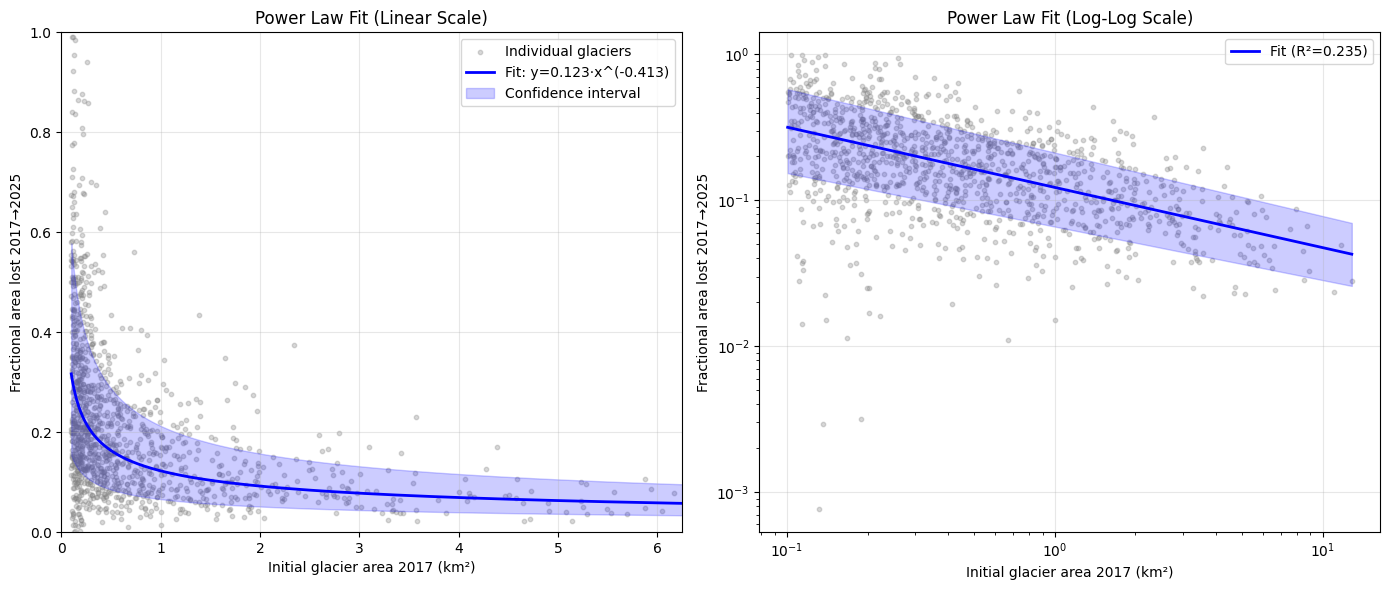

Plot saved


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raw data
x_plot = np.logspace(np.log10(fit_df['area_2017_km2'].min()),
                      np.log10(fit_df['area_2017_km2'].max()), 200)
y_fit   = a       * x_plot ** (-b)
y_upper = a_upper * x_plot ** (-b_upper)
y_lower = a_lower * x_plot ** (-b_lower)

# Linear scale
ax = axes[0]
ax.scatter(fit_df['area_2017_km2'], fit_df['fraction_lost_8yr'],
           alpha=0.3, s=10, color='gray', label='Individual glaciers')
ax.plot(x_plot, y_fit,   'b-',  linewidth=2, label=f'Fit: y={a:.3f}·x^(-{b:.3f})')
ax.fill_between(x_plot, y_lower, y_upper, alpha=0.2, color='blue', label='Confidence interval')
ax.set_xlabel('Initial glacier area 2017 (km²)')
ax.set_ylabel('Fractional area lost 2017→2025')
ax.set_title('Power Law Fit (Linear Scale)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, fit_df['area_2017_km2'].quantile(0.99))
ax.set_ylim(0, 1)

# Log-log scale
ax = axes[1]
ax.scatter(fit_df['area_2017_km2'], fit_df['fraction_lost_8yr'],
           alpha=0.3, s=10, color='gray')
ax.plot(x_plot, y_fit,   'b-',  linewidth=2, label=f'Fit (R²={r2:.3f})')
ax.fill_between(x_plot, y_lower, y_upper, alpha=0.2, color='blue')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Initial glacier area 2017 (km²)')
ax.set_ylabel('Fractional area lost 2017→2025')
ax.set_title('Power Law Fit (Log-Log Scale)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'power_law_fit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [10]:
# Save coefficients
coefficients = {
    'a': a, 'b': b,
    'a_upper': a_upper, 'b_upper': b_upper,
    'a_lower': a_lower, 'b_lower': b_lower,
    'r2': r2,
    'n_glaciers_fit': len(fit_df)
}
pd.Series(coefficients).to_json(RESULTS_DIR / 'power_law_coefficients.json')
print("Coefficients saved:")
for k, v in coefficients.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

# Save per-glacier area data
glacier_areas.to_parquet(RESULTS_DIR / 'glacier_areas_2017_2025.parquet')
print(f"\nGlacier areas saved: {len(glacier_areas):,} glaciers")

Coefficients saved:
  a: 0.1226
  b: 0.4129
  a_upper: 0.2126
  b_upper: 0.4351
  a_lower: 0.0661
  b_lower: 0.3671
  r2: 0.2351
  n_glaciers_fit: 1235

Glacier areas saved: 2,664 glaciers
